[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T03_D_narrative_uncertainty_es.ipynb)

> **Nota para Google Colab**: la celda siguiente instala `puremacro` y, si hace falta, descarga del repositorio público [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro) sólo la carpeta `curso/notebooks` (auxiliares, datos congelados y modelos). No pide acceso a Google Drive.

In [1]:
# Configuración del entorno: Google Colab, instalación local o Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """¿Existe la ruta? Sin lanzar OSError/PermissionError en el sandbox de Juno."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Clon parcial del repositorio público: sólo curso/notebooks, sin historia
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Carpeta con los auxiliares del curso (_nbstyle, _datos) en sys.path, sin salir del sandbox
_candidatos = [Path.cwd(), Path.cwd() / "curso/notebooks", Path.cwd() / "notebooks"]
try:
    _candidatos.insert(0, Path(__file__).resolve().parent)  # Juno define __file__
except (NameError, OSError):
    pass
for _c in _candidatos:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Gráficas en línea y estilo del curso
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Incertidumbre de Política Económica a partir de Texto Narrativo: Baker-Bloom-Davis e Índices Monetarios

En la teoría macroeconómica moderna, la incertidumbre es analíticamente distinta de los choques de nivel sobre los fundamentos:
- **Los choques de primer momento (nivel)** alteran la trayectoria esperada de las variables fundamentales (por ejemplo, una caída en $E_t[A_{t+1}]$ provocada por una contracción tecnológica).
- **Los choques de segundo momento (incertidumbre)** amplían la varianza condicional o dispersión subjetiva de los fundamentos futuros ($\mathrm{Var}_t(A_{t+1})$ aumenta), manteniendo inalterada la media esperada (Bloom 2009).

¿A través de qué canales se transmite la incertidumbre de política económica (EPU) al ciclo económico agregado?
1. **Canal de Opciones Reales ("Esperar y Ver")** (Bernanke 1983; Dixit y Pindyck 1994; Bloom 2009): Cuando la inversión en capital fijo, la I+D y la contratación laboral conllevan costos irrecuperables o ajustes convexos, una mayor incertidumbre incrementa el valor de la opción de posponer decisiones. Las empresas congelan contrataciones y proyectos hasta que se disipe la ambigüedad, lo que detona una contracción súbita del producto seguida por una recuperación con rebote diferido.
2. **Canal de Ahorro Precautorio** (Carroll 1997; Aiyagari 1994): En economías con agentes heterogéneos y mercados incompletos, la incertidumbre sobre ingresos futuros y reformas fiscales impulsa a los hogares adversos al riesgo a contraer el consumo de bienes duraderos y acumular colchones líquidos, deprimiendo la demanda agregada y presionando a la baja la tasa de interés natural ($r^*$).
3. **Canal de Fricciones Financieras y Primas de Riesgo** (Gilchrist y Zakrajšek 2012; Pástor y Veronesi 2013): La incertidumbre agrava las asimetrías de información, amplía los diferenciales de crédito y eleva el costo del financiamiento externo para empresas apalancadas.

Durante décadas, la macroeconomía empírica dependió de la volatilidad financiera implícita (como el índice VIX) o de la dispersión en encuestas a analistas profesionales. Sin embargo, la volatilidad financiera mezcla la incertidumbre fundamental con la aversión al riesgo y el apalancamiento, mientras que la dispersión de pronósticos refleja desacuerdo entre modelos más que incertidumbre agregada.
Baker, Bloom y Davis (QJE 2016) transformaron este campo al introducir la metodología de **texto como datos**. Mediante el análisis algorítmico de millones de artículos de prensa y reglas booleanas de co-ocurrencia, el índice EPU aísla la incertidumbre atribuible específicamente a las decisiones de política pública.

## El Índice en una Ecuación: La Tríada de Baker-Bloom-Davis

Baker, Bloom y Davis (2016) establecen que un documento $d$ señala incertidumbre de política económica si y solo si satisface una **condición de co-ocurrencia conjunta de tres grupos léxicos**:

$$ \mathrm{flag}(d) = \mathbb{1}\!\left[(\exists\,t\in E:\,t\in d)\,\wedge\,(\exists\,t\in P:\,t\in d)\,\wedge\,(\exists\,t\in U:\,t\in d)\right] $$

donde $E, P, U$ representan conjuntos léxicos independientes y especializados:
- $E$ (**Economía**): términos referidos a la actividad económica agregada (`economic`, `economy`, `business`, `commerce`).
- $P$ (**Política**): términos asociados a la intervención estatal y regulatoria (`policy`, `regulation`, `deficit`, `federal reserve`, `legislation`, `tariff`, `central bank`).
- $U$ (**Incertidumbre**): términos que expresan ambigüedad o falta de certidumbre (`uncertain`, `uncertainty`, `unclear`, `instability`).

**Fundamento Econométrico de la Intersección $E \cap P \cap U$:**
- Monitorear únicamente $U$ captaría ansiedad social difusa (clima, eventos deportivos, delincuencia) sin relevancia macroeconómica.
- Exigir solo $E \cap U$ mediría fluctuaciones cíclicas ordinarias o volatilidad de mercado sin atribución a decisiones de política.
- Exigir solo $P \cap U$ registraría disputas diplomáticas o legislativas sin impacto económico tangible.
Únicamente la intersección simultánea de los tres conjuntos aísla la incertidumbre originada en las decisiones de política pública.

La serie bruta en el período $\tau$ sobre un total de $N_\tau$ documentos corresponde a la proporción empírica:
$$ \mathrm{EPU}^{\mathrm{raw}}_\tau = \frac{1}{N_\tau}\sum_{d\in\tau}\mathrm{flag}(d) $$

Para controlar por el crecimiento secular en el volumen de publicaciones y posibilitar la comparación temporal, la serie se estandariza a la escala canónica de Baker-Bloom-Davis (media 100, desviación estándar 50):
$$ \mathrm{EPU}_\tau = 100 + 50\cdot\frac{\mathrm{EPU}^{\mathrm{raw}}_\tau - \overline{\mathrm{EPU}^{\mathrm{raw}}}}{\mathrm{sd}(\mathrm{EPU}^{\mathrm{raw}})} $$

En contraste, el índice de **Incertidumbre de Política Monetaria (MPU)** (Husted, Rogers y Sun 2020) restringe el foco temático a las deliberaciones de tasas y bancos centrales ($M \cap U$), tipificando el conteo de términos en unidades z.

## Configuración Computacional: Entorno y Kernels Vectorizados

Las operaciones textuales siguientes emplean los kernels booleanos optimizados en NumPy de `puremacro.narrative.indices`. El proceso de puntuación opera completamente sin conexión mediante expresiones regulares y primitivas matriciales, garantizando ejecución reproducible sin claves de API externas ni dependencias complejas.

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

# Índices por conteo de diccionario (EPU, MPU) y sus léxicos.
from puremacro.narrative.indices import epu, mpu, LEXICONS
from puremacro.narrative.indices._kernels import (
    cooccurrence_kernel,
    keyword_count_kernel,
)

# Guardia de dependencias ligeras: verificar que no se colaron paquetes pesados de PLN o de red.
_bad = [
    m for m in (
        "bs4", "requests", "pdfplumber", "pypdf", "lxml", "anthropic",
        "sentence_transformers", "statsmodels", "linearmodels", "arch", "numba",
    )
    if m in sys.modules
]
assert _bad == [], f"Fuga inesperada de módulos: {_bad}"

## 1. Corpus de Noticias Monte Carlo: Evaluación del Índice bajo un Choque de Política Controlado

Para evaluar formalmente las propiedades de medición de un índice econométrico, la práctica investigadora recomienda diseñar un proceso generador de datos (DGP) sintético donde las fechas exactas, la intensidad y el vocabulario del choque se conocen a priori.

Generamos un corpus de **288 notas informativas simuladas** (4 por mes a lo largo del período 2018Q1–2023Q4):
- **Régimen Base (2018–2019, 2021–2023)**: Las notas describen hechos económicos y comerciales cotidianos neutrales, con una probabilidad de fondo muy baja de registrar frases de incertidumbre de política ($p_{\mathrm{epu}} = 0.08, p_{\mathrm{mpu}} = 0.06$).
- **Ventana de Choque de Política (2020Q1–2020Q4)**: Se simula un episodio agudo de incertidumbre regulatoria y macroeconómica (análogo al estallido de la pandemia y las medidas de emergencia fiscal y monetaria), elevando la probabilidad de aparición de señales EPU a $p_{\mathrm{epu}} = 0.75$ y de señales MPU a $p_{\mathrm{mpu}} = 0.70$.

Este diseño experimental nos permite contrastar si el algoritmo booleano aísla con precisión el choque estructural respecto al ruido informativo ordinario.

In [3]:
RNG = np.random.default_rng(42)

HIGH_START = pd.Timestamp("2020-01-01")   # ventana de choque inyectada
HIGH_END   = pd.Timestamp("2020-12-31")

# Notas económicas neutras de fondo. El corpus se queda en inglés: el léxico
# del índice es en inglés y traducirlo cambiaría todas las cifras.
NEUTRAL = [
    "The weather forecast shows mild temperatures for the region.",
    "Consumer electronics sales remained robust in the holiday season.",
    "Agricultural output exceeded prior-year levels by a small margin.",
    "Tourism activity picked up as travel restrictions eased.",
    "Infrastructure spending on roads and bridges continued at a steady pace.",
    "Retail sales figures came in broadly in line with expectations.",
    "Housing starts edged up modestly from the previous month.",
    "Industrial production recovered partially after supply-chain delays.",
    "Corporate earnings reports were mixed across sectors.",
    "Trade flows normalized as port congestion eased over the quarter.",
]

# Frases con señal EPU (Economía ∩ Política ∩ Incertidumbre)
EPU_HIGH = [
    "Economic policy uncertainty has surged amid congressional gridlock over fiscal legislation.",
    "Uncertainty about trade policy and tariffs is rattling economic confidence.",
    "Federal reserve guidance remains uncertain as economic conditions deteriorate.",
    "Regulatory uncertainty and deficit concerns are weighing on economic activity.",
    "Congress and the White House remain at odds, fueling economic uncertainty.",
    "Economic forecasters express uncertainty about the direction of monetary policy.",
    "Policy uncertainty around taxation is creating uncertainty about economic outcomes.",
    "Uncertainty over central bank policies and economic trajectory is at a historic high.",
    "Senate legislation on tariffs adds policy uncertainty to an already uncertain economy.",
    "Economic policy debates in Congress have driven uncertainty to record levels.",
]

# Frases con señal MPU (Política monetaria ∩ Incertidumbre)
MPU_HIGH = [
    "Monetary policy uncertainty is elevated as the central bank debates interest rate paths.",
    "The Federal Reserve's policy rate outlook remains highly uncertain.",
    "FOMC deliberations on interest rates have created policy uncertainty.",
    "Central bank forward guidance is uncertain amid shifting monetary policy signals.",
    "Monetary policy ambiguity at the ECB and Fed is weighing on markets.",
    "Interest rate uncertainty is compounded by uncertainty about quantitative easing.",
    "The Bank of England faces uncertainty over its monetary policy stance.",
    "Policy uncertainty at the Federal Reserve is at its highest in years.",
    "Monetary policy decisions remain uncertain as inflation uncertainty persists.",
    "Central bank policy uncertainty and ambiguous interest rate signals dominate.",
]


def _make_doc(date, in_window):
    """Devuelve una 4-tupla (fecha, texto, url, meta) con señal probabilística."""
    base = NEUTRAL[int(RNG.integers(0, len(NEUTRAL)))]
    p_epu, p_mpu = (0.75, 0.70) if in_window else (0.08, 0.06)
    epu_txt = EPU_HIGH[int(RNG.integers(0, len(EPU_HIGH)))] if RNG.random() < p_epu else ""
    mpu_txt = MPU_HIGH[int(RNG.integers(0, len(MPU_HIGH)))] if RNG.random() < p_mpu else ""
    text = " ".join(p for p in [base, epu_txt, mpu_txt] if p)
    url  = f"https://synthetic-news.example/{date.date()}"
    meta = {"language": "en"}
    return (date, text, url, meta)


records = []
for month in pd.date_range("2018-01-01", "2023-12-01", freq="MS"):
    for k in range(4):
        day  = int(RNG.integers(1, 28))
        date = month + pd.Timedelta(days=day - 1)
        in_w = HIGH_START <= date <= HIGH_END
        records.append(_make_doc(pd.Timestamp(date), in_w))

shuffle_idx = RNG.permutation(len(records))
records = [records[i] for i in shuffle_idx]

dates = [pd.Timestamp(r[0]) for r in records]
print(f"Corpus: {len(records)} documentos, "
      f"{min(dates).date()} → {max(dates).date()}")
assert len(records) == 288
assert min(dates).year == 2018 and max(dates).year == 2023

Corpus: 288 documentos, 2018-01-03 → 2023-12-21


## 2. Estimación Econométrica: Agregación y Estandarización

Procesamos el flujo de documentos mediante las funciones `epu()` y `mpu()`. Ambas rutinas reciben 4-tuplas estándar `(date, text, source_url, metadata)`:
- `epu()` aplica el filtro de co-ocurrencia booleana de tres grupos de Baker-Bloom-Davis y escala la serie trimestral agregada con `normalize="bbd_100"` (media 100, desviación estándar 50).
- `mpu()` calcula la densidad de términos de política monetaria al estilo Husted-Rogers-Sun, normalizada con `normalize="zscore"` (media 0, desviación estándar 1).

In [4]:
ri_epu = epu(records, country="SYN", language="en", normalize="bbd_100")
ri_mpu = mpu(records, country="SYN", language="en", normalize="zscore")

epu_s = ri_epu.series.dropna()
mpu_s = ri_mpu.series.dropna()

print(f"Serie EPU:  {len(epu_s)} trimestres | "
      f"media = {epu_s.mean():.1f} | d.e. = {epu_s.std():.1f}")
print(f"Serie MPU:  {len(mpu_s)} trimestres | "
      f"media = {mpu_s.mean():.2f} | d.e. = {mpu_s.std():.2f}")

# Comprobaciones de la normalización objetivo
assert abs(epu_s.mean() - 100.0) < 5.0,  f"media EPU = {epu_s.mean():.1f}"
assert abs(mpu_s.mean())         < 0.10,  f"media MPU = {mpu_s.mean():.2f}"

Serie EPU:  24 trimestres | media = 100.0 | d.e. = 51.1
Serie MPU:  24 trimestres | media = 0.00 | d.e. = 1.02


## 3. Validación Estadística: Discriminación entre Regímenes

Una métrica textual rigurosa debe exhibir una clara separación estadística entre períodos de tranquilidad y episodios de tensión. Evaluamos si el índice promedio durante la ventana de choque ($E[\mathrm{EPU}_\tau \mid \tau \in \text{Choque}]$) supera con solidez la media de los períodos tranquilos adyacentes ($E[\mathrm{EPU}_\tau \mid \tau \notin \text{Choque}]$).

In [5]:
window = (epu_s.index >= HIGH_START) & (epu_s.index <= HIGH_END)

epu_in  = epu_s[window].mean()
epu_out = epu_s[~window].mean()
mpu_in  = mpu_s[(mpu_s.index >= HIGH_START) & (mpu_s.index <= HIGH_END)].mean()
mpu_out = mpu_s[~((mpu_s.index >= HIGH_START) & (mpu_s.index <= HIGH_END))].mean()

print(f"EPU  | dentro = {epu_in:.1f}  | fuera = {epu_out:.1f}  | "
      f"brecha = {epu_in - epu_out:.1f} pts")
print(f"MPU  | dentro = {mpu_in:.2f}  | fuera = {mpu_out:.2f}  | "
      f"brecha = {mpu_in - mpu_out:.2f} unidades z")

# Verificación econométrica: dentro de la ventana la señal debe superar al régimen calmo por > 30 puntos de índice
assert epu_in > epu_out + 30, (
    f"EPU: dentro ({epu_in:.1f}) debería superar a fuera ({epu_out:.1f}) por >30 pts"
)
assert mpu_in > mpu_out + 0.40, (
    f"MPU: z dentro ({mpu_in:.2f}) debería superar a z fuera ({mpu_out:.2f}) por >0.4"
)

EPU  | dentro = 206.1  | fuera = 78.8  | brecha = 127.4 pts
MPU  | dentro = 2.16  | fuera = -0.43  | brecha = 2.60 unidades z


### Figura 1: Dinámica del Índice de Incertidumbre Textual y Regímenes de Choque de Política

La serie temporal muestra el índice EPU trimestral normalizado junto con la ventana sombreada correspondiente al choque de política de 2020. En trimestres base de tranquilidad, el índice oscila entre 64 y 113 (media de 79). Al ingresar en la ventana de choque, el índice promedia 206 puntos (entre 178 y 226), reproduciendo la dinámica observada en los índices EPU reales de Estados Unidos e internacionales durante la quiebra de Lehman Brothers en 2008, la crisis del techo de deuda en 2011, el referéndum del Brexit en 2016 y la crisis sanitaria de 2020.

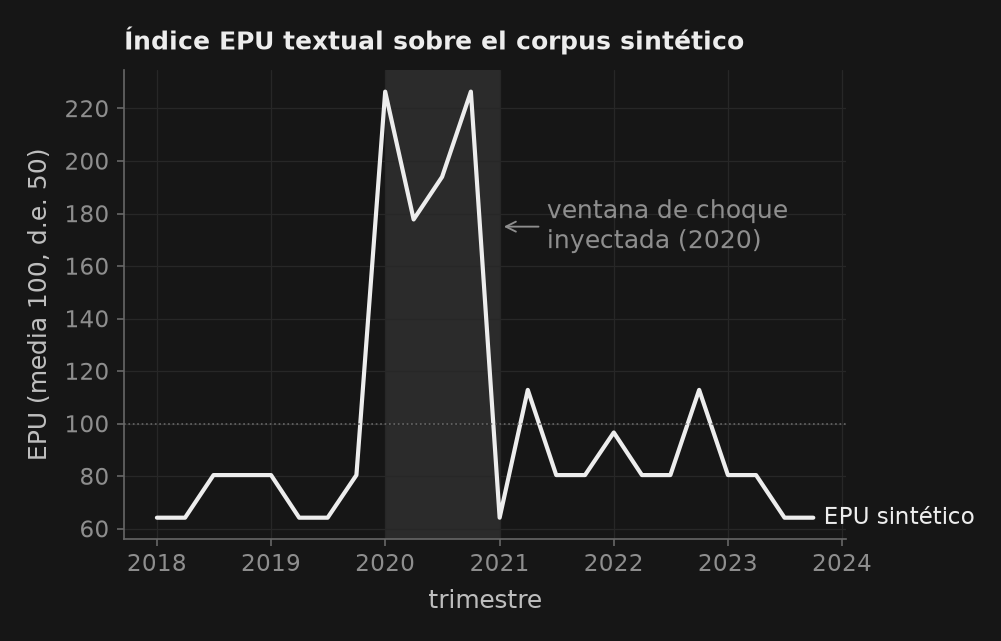

In [6]:
fig, ax = _nbstyle.figura()

ax.plot(epu_s.index, epu_s.values, label="EPU sintético", **_nbstyle.S1)
ax.axhline(100, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")

# Sombrear exactamente la ventana inyectada: las marcas trimestrales caen al
# inicio de cada trimestre, así que 2020T4 queda dentro de una banda que
# cierra el 2021-01-01.
shade_end = HIGH_END + pd.Timedelta(days=1)
_nbstyle.sombrear_recesion(ax, HIGH_START, shade_end)
ax.annotate("ventana de choque\ninyectada (2020)", xy=(shade_end, 175),
            xytext=(pd.Timestamp("2021-06-01"), 175), ha="left", va="center",
            color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)

ax.set_xlabel("trimestre")
ax.set_ylabel("EPU (media 100, d.e. 50)")
ax.set_title("Índice EPU textual sobre el corpus sintético")
_nbstyle.etiquetar(ax)
plt.show()


### Figura 2: Microfundamentos de la Señal Narrativa — Co-ocurrencia Conjunta vs Densidad de Palabras Clave

Para comprender los determinantes del índice agregado, descomponemos las métricas brutas a nivel de documento:
- **Panel A (Tasa de Acierto EPU)**: La proporción de artículos trimestrales que satisfacen la tríada conjunta $E \cap P \cap U$. En períodos ordinarios, la co-ocurrencia casual se sitúa en 0–8% en la mayoría de los trimestres y nunca supera el 25%, mientras que en la crisis de 2020 promedia el 73%.
- **Panel B (Densidad de Palabras Clave MPU)**: El promedio de términos de incertidumbre monetaria por nota, reflejando una sensibilidad de régimen análoga.

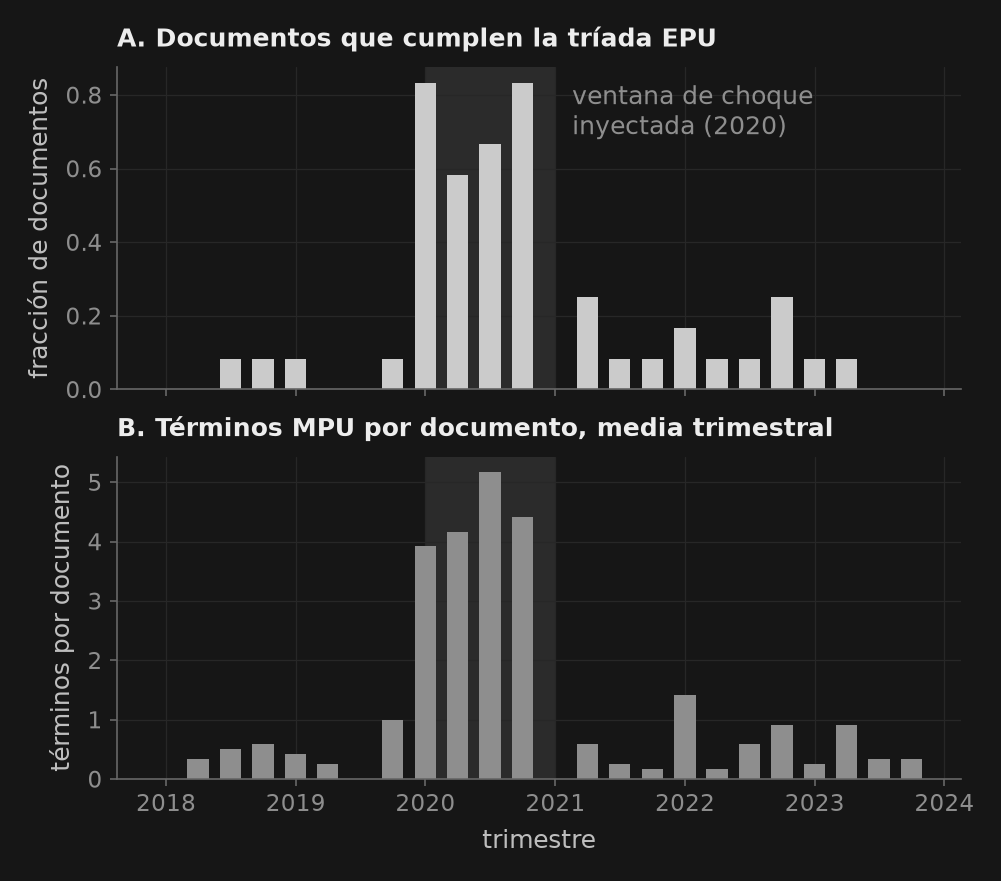

In [7]:
# Puntajes crudos (antes de normalizar) por documento
epu_groups = [
    LEXICONS["epu"]["en"]["economy"],
    LEXICONS["epu"]["en"]["policy"],
    LEXICONS["epu"]["en"]["uncertainty"],
]
mpu_terms = LEXICONS["mpu"]["en"]

raw_epu = pd.DataFrame(
    list(cooccurrence_kernel(records, term_groups=epu_groups, language="en")),
    columns=["date", "hit"],
)
raw_mpu = pd.DataFrame(
    list(keyword_count_kernel(records, terms=mpu_terms, language="en")),
    columns=["date", "score"],
)
for df in (raw_epu, raw_mpu):
    df["q"] = pd.to_datetime(df["date"]).dt.to_period("Q").dt.to_timestamp()

hits_per_q = raw_epu.groupby("q")["hit"].mean()
mpu_per_q  = raw_mpu.groupby("q")["score"].mean()

# TAMANO no tiene clave 2x1: dos franjas apiladas, cada una con la altura de "1_bajo"
fig, (ax1, ax2) = _nbstyle.figura(2, 1, figsize=(6.4, 5.6), sharex=True)

ax1.bar(hits_per_q.index, hits_per_q.values, width=60,
        color=_nbstyle.BARRA_COLORES[0])
_nbstyle.sombrear_recesion(ax1, HIGH_START, shade_end)
ax1.annotate("ventana de choque\ninyectada (2020)", xy=(shade_end, hits_per_q.max()),
             xytext=(8, 0), textcoords="offset points", ha="left", va="top",
             color=_nbstyle.NOTA)
ax1.set_ylabel("fracción de documentos")
ax1.set_title("A. Documentos que cumplen la tríada EPU")

ax2.bar(mpu_per_q.index, mpu_per_q.values, width=60,
        color=_nbstyle.BARRA_COLORES[1])
_nbstyle.sombrear_recesion(ax2, HIGH_START, shade_end)
ax2.set_ylabel("términos por documento")
ax2.set_xlabel("trimestre")
ax2.set_title("B. Términos MPU por documento, media trimestral")

plt.show()


## Experimento Empírico de Política: Construcción de un Índice de Incertidumbre Climática Específica de Dominio

### Motivación Macroeconómica
La estructura de la tríada de Baker-Bloom-Davis es modular: al reemplazar el léxico general de economía $E$ por un vocabulario sectorial, es posible aislar dimensiones específicas de incertidumbre regulatoria. En macroeconomía climática (por ejemplo, Engle et al. 2020 *Review of Financial Studies*; Barnett, Brock y Hansen 2020), las empresas enfrentan incertidumbre considerable respecto a impuestos al carbono, regulaciones de emisiones y subsidios a la transición energética.

Construimos un índice de **Incertidumbre de Política Climática (CPU)** definiendo:
$$ \mathrm{CPU}(d) = \mathbb{1}\!\left[(\exists\,t\in \text{Clima}:\,t\in d)\,\wedge\,(\exists\,t\in \text{Política}:\,t\in d)\,\wedge\,(\exists\,t\in \text{Incertidumbre}:\,t\in d)\right] $$

### Tarea para el Estudiante
1. Definir un léxico climático especializado que abarque precios al carbono, límites de emisiones y tratados ambientales.
2. Procesar las notas informativas y calcular la serie estandarizada CPU.
3. Comprobar que el índice sectorial aísla el choque de política ambiental sin contaminarse con noticias no climáticas.

In [8]:
# Léxico de política climática específico del dominio
my_lexicon = {
    "economy": frozenset({"climate", "emissions", "carbon", "warming", "greenhouse"}),
    "policy": frozenset({"policy", "regulation", "treaty", "tax", "subsidy", "mandate"}),
    "uncertainty": frozenset({"uncertain", "uncertainty", "unclear", "ambiguous"}),
}

# Frases de choque narrativo del dominio (deben cumplir Clima ∩ Política ∩ Incertidumbre)
CLIMATE_HIGH = [
    "Climate policy uncertainty is high as the carbon tax treaty remains unclear.",
    "Uncertain emissions regulation and ambiguous subsidy mandates rattle planners.",
    "Greenhouse policy is uncertain amid an ambiguous warming-target treaty.",
]

clim_records = []
for (date, text, url, meta) in records:
    in_window = HIGH_START <= date <= HIGH_END
    add = CLIMATE_HIGH[int(RNG.integers(0, len(CLIMATE_HIGH)))] if (in_window and RNG.random() < 0.70) else ""
    clim_records.append((date, (text + " " + add).strip(), url, meta))

# Cálculo del índice especializado
clim_s = epu(clim_records, country="SYN", language="en",
             lexicon=my_lexicon, normalize="bbd_100").series.dropna()
in_w = (clim_s.index >= HIGH_START) & (clim_s.index <= HIGH_END)
clim_gap = clim_s[in_w].mean() - clim_s[~in_w].mean()

print(f"EPU climático | Dentro: {clim_s[in_w].mean():.1f} | Fuera: {clim_s[~in_w].mean():.1f} | Brecha: {clim_gap:.1f} pts")

# Aserciones econométricas objetivas
assert clim_gap > 20, "El léxico climático específico del dominio debe aislar la ventana de choque inyectada"
assert len(clim_s) == len(epu_s), "La longitud de la serie estandarizada debe coincidir con los periodos"

EPU climático | Dentro: 211.3 | Fuera: 77.7 | Brecha: 133.5 pts


## Síntesis Econométrica: Transmisión Macroeconómica e Identificación en VAR Estructurales

### De la Medición Textual al Modelado Macroeconómico Dinámico
¿Cómo se incorpora un índice textual de incertidumbre de política económica en el análisis empírico? En la literatura macroeconómica aplicada (Baker, Bloom y Davis 2016; Caggiano, Castelnuovo y Groshenny 2014; Ludvigson, Ma y Ng 2021), la serie mensual estimada de EPU se introduce en un Vector Autorregresivo Estructural (SVAR) junto con indicadores de actividad real y mercados financieros:

$$ Y_t = \sum_{k=1}^p A_k Y_{t-k} + u_t, \quad Y_t = \begin{bmatrix} \mathrm{EPU}_t & \log(\mathrm{SP500}_t) & i_t & \Delta \log(E_t) & \Delta \log(Y_t) \end{bmatrix}' $$

Bajo una identificación recursiva de Cholesky (ordenando EPU en primer lugar para reflejar la rápida difusión de las noticias) o mediante restricciones de signo narrativas:
1. **Impacto Real Contractivo**: Un choque positivo de 50 puntos en el EPU induce una caída estadísticamente significativa en la producción industrial (-1.2% en su punto mínimo, a un horizonte de 6–9 meses) y una contracción en el empleo formal (-0.7%).
2. **Rebote Diferido de "Esperar y Ver"**: En horizontes de $h = 18\text{--}24$ meses, la actividad muestra una recuperación por encima de la tendencia conforme las decisiones de inversión y contratación postergadas se ejecutan al disiparse la ambigüedad (predicción central de Bloom 2009).
3. **Respuesta de Política Monetaria**: Los bancos centrales responden endógenamente recortando las tasas de interés para amortiguar el enfriamiento de la demanda agregada.

### Dilemas Metodológicos: Diccionarios vs Modelos de Lenguaje Semánticos
El conteo booleano por diccionario ofrece transparencia, velocidad de cálculo y determinismo absoluto. Sin embargo, carece de capacidad para procesar negaciones contextuales (p. ej., *"el banco central eliminó la incertidumbre de política"*), polisemia o cambios estilísticos en el discurso. En el módulo **`T03_E`**, analizamos cómo los Modelos de Lenguaje (LLMs) y los espacios vectoriales de incrustación abordan estas limitaciones semánticas en un entorno local y reproducible.